<b><font size="6">Credit Card Costumer Unsupervized Learning</font></b><br><br>

In [22]:
import numpy as np
import pandas as pd
import sklearn as skl
import copy
import warnings
warnings.filterwarnings('ignore')
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score,  recall_score, classification_report,  balanced_accuracy_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from matplotlib.colors import ListedColormap
import seaborn as sns 
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import plotly

<b><font size="5">Initial Assessment</font></b><br><br>

In [111]:
data = pd.read_csv(r"C:\Users\inesb\Downloads\ML_unsupervized_learning_26\CC GENERAL.csv")
data.head(-20)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8925,C19166,101.564003,1.000000,418.59,0.00,418.59,0.000000,0.833333,0.000000,0.500000,0.000000,0,5,1000.0,422.538988,81.389378,0.500000,6
8926,C19167,53.097361,0.833333,580.00,0.00,580.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,641.303466,52.453011,0.666667,6
8927,C19168,91.639086,1.000000,315.20,147.80,167.40,0.000000,1.000000,0.333333,0.833333,0.000000,0,8,1000.0,231.274641,86.344733,0.250000,6
8928,C19169,62.320028,1.000000,500.00,0.00,500.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,456.745027,73.848755,1.000000,6


In [112]:
data.info()
# 1 missing value at Credit_Limit
# 313 missing values at Minimum_Payments

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

<b><font size="5">Data Preprocessing</font></b><br><br>

In [113]:
print("----------------Handling missing values:-------------------")
print(len(data[data.isnull().any(axis=1)]))
# Deleting the one row with Credit Limit's null value
data_droped = data.dropna(subset = ['CREDIT_LIMIT'])
# Filling in the rows with Minimum Payments' null values with the median, since its distribution is skewed:
data_droped['MINIMUM_PAYMENTS'] = data_droped['MINIMUM_PAYMENTS'].fillna(data['MINIMUM_PAYMENTS'].median())
data_droped.info()

----------------Handling missing values:-------------------
314
<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8949 non-null   object 
 1   BALANCE                           8949 non-null   float64
 2   BALANCE_FREQUENCY                 8949 non-null   float64
 3   PURCHASES                         8949 non-null   float64
 4   ONEOFF_PURCHASES                  8949 non-null   float64
 5   INSTALLMENTS_PURCHASES            8949 non-null   float64
 6   CASH_ADVANCE                      8949 non-null   float64
 7   PURCHASES_FREQUENCY               8949 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8949 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8949 non-null   float64
 11  CASH_ADVAN

In [114]:
print("----------------Handling the unique identifier:-----------------------")
# Checking the pattern is fully repeated in Cust_ID variable
print(data_droped["CUST_ID"].str.match(r"^[A-Za-z]\d+$").all())
data_droped["CUST_ID"] = data_droped["CUST_ID"].str[1:]
data_droped["CUST_ID"] = pd.to_numeric(data_droped["CUST_ID"])

----------------Handling the unique identifier:-----------------------
True


In [115]:
print("----------------Incoherence Checking:-----------------------")
print(data_droped[(data_droped["PURCHASES_TRX"] == 0) & (data_droped["PURCHASES"] != 0)][["CUST_ID", "PURCHASES"]])
data_droped.drop(data_droped[data_droped["CUST_ID"].isin([11506, 13691, 14622])].index, inplace = True)
print(data_droped[(data_droped["PURCHASES_TRX"] == 0) & (data_droped["PURCHASES"] != 0)])
print(data_droped[(data_droped["CASH_ADVANCE_TRX"] == 0) & (data_droped["CASH_ADVANCE"] != 0)][["CUST_ID", "CASH_ADVANCE"]])
print(data_droped[(data_droped["MINIMUM_PAYMENTS"] == 0)])
print(len(data_droped[(data_droped["MINIMUM_PAYMENTS"] > data_droped["PAYMENTS"])][["CUST_ID", "PAYMENTS", "MINIMUM_PAYMENTS"]]))
print(f"This represents ~{round(len(data_droped[(data_droped['MINIMUM_PAYMENTS'] > data_droped['PAYMENTS'])]) / len(data_droped) * 100, 2)}% of the data, suggesting revolving debt or partial payment behavior, which is common in credit card usage.")
print(data_droped[(data_droped.select_dtypes(include='number') < 0).any(axis=1)])

----------------Incoherence Checking:-----------------------
      CUST_ID  PURCHASES
1458    11506     130.24
3590    13691       0.24
4497    14622     655.68
Empty DataFrame
Columns: [CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE]
Index: []
Empty DataFrame
Columns: [CUST_ID, CASH_ADVANCE]
Index: []
Empty DataFrame
Columns: [CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE]
Index: []
2637
This represents ~29.48% of the data, suggesting revolving debt or partial payme

In [116]:
print("----------------Exploring Multicollinearity:-----------------------")
threshold = 0.8
corr_matrix = data_droped.corr(method = 'spearman').abs()
high_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))
readable = (high_corr.stack().reset_index().rename(columns = {'level_0': 'var1', 'level_1': 'var2', 0: 'corr'}))
high_pairs = readable[readable['corr'] > threshold]
print(high_pairs)

----------------Exploring Multicollinearity:-----------------------
                       var1                              var2      corr
30                  BALANCE                  MINIMUM_PAYMENTS  0.871699
56                PURCHASES                     PURCHASES_TRX  0.885290
65         ONEOFF_PURCHASES        ONEOFF_PURCHASES_FREQUENCY  0.952397
78   INSTALLMENTS_PURCHASES  PURCHASES_INSTALLMENTS_FREQUENCY  0.923409
90             CASH_ADVANCE            CASH_ADVANCE_FREQUENCY  0.940723
91             CASH_ADVANCE                  CASH_ADVANCE_TRX  0.951790
99      PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  0.851539
102     PURCHASES_FREQUENCY                     PURCHASES_TRX  0.923936
125  CASH_ADVANCE_FREQUENCY                  CASH_ADVANCE_TRX  0.983414


In [ ]:
print("----------------Feature Engineering:-----------------------")
data_droped["AVG_PURCHASE_VALUE"] = np.where(data_droped["PURCHASES_TRX"] > 0, data_droped["PURCHASES"] / data_droped["PURCHASES_TRX"], 0)
data_droped["AVG_CASH_ADVANCE_VALUE"] = np.where(data_droped["CASH_ADVANCE_TRX"] > 0, data_droped["CASH_ADVANCE"] / data_droped["CASH_ADVANCE_TRX"], 0)

data_droped["PURCHASE_ENGAGEMENT"] = np.log(1 + data_droped["PURCHASES"] * data_droped["PURCHASES_FREQUENCY"])
data_droped["INSTALLMENT_PURCHASES_ENGAGEMENT"] = np.log(1 + data_droped["INSTALLMENTS_PURCHASES"] * data_droped["PURCHASES_INSTALLMENTS_FREQUENCY"])

data_droped["PAYMENT_RATIO"] = np.log(1 + data_droped["PAYMENTS"] / data_droped["MINIMUM_PAYMENTS"])
data_droped.drop(columns = ["CASH_ADVANCE", "PURCHASES_FREQUENCY", "PURCHASES", "INSTALLMENTS_PURCHASES", "ONEOFF_PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY",
                            "CASH_ADVANCE_TRX", "PURCHASES_TRX", "PURCHASES_INSTALLMENTS_FREQUENCY", "MINIMUM_PAYMENTS"], inplace = True)
data_droped.info()

----------------Feature Engineering:-----------------------
<class 'pandas.core.frame.DataFrame'>
Index: 8946 entries, 0 to 8949
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CUST_ID                          8946 non-null   int64  
 1   BALANCE                          8946 non-null   float64
 2   BALANCE_FREQUENCY                8946 non-null   float64
 3   ONEOFF_PURCHASES                 8946 non-null   float64
 4   CREDIT_LIMIT                     8946 non-null   float64
 5   PAYMENTS                         8946 non-null   float64
 6   PRC_FULL_PAYMENT                 8946 non-null   float64
 7   TENURE                           8946 non-null   int64  
 8   AVG_PURCHASE_VALUE               8946 non-null   float64
 9   AVG_CASH_ADVANCE_VALUE           8946 non-null   float64
 10  PURCHASE_INTENSITY               8946 non-null   float64
 11  INSTALLMENT_PURCHASES_INTEN

In [118]:
corr_matrix = data_droped.corr(method = 'spearman').abs()
high_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))
readable = (high_corr.stack().reset_index().rename(columns = {'level_0': 'var1', 'level_1': 'var2', 0: 'corr'}))
high_pairs = readable[readable['corr'] > threshold]
print(high_pairs)

Empty DataFrame
Columns: [var1, var2, corr]
Index: []


In [119]:
data_droped.describe()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,ONEOFF_PURCHASES,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE,AVG_PURCHASE_VALUE,AVG_CASH_ADVANCE_VALUE,PURCHASE_INTENSITY,INSTALLMENT_PURCHASES_INTENSITY,PAYMENT_RATIO
count,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000,8946.000000
mean,14600.401967,1565.163495,0.877451,592.702239,4493.944571,1730.580208,0.153690,11.517773,73.903713,208.977637,4.376260,3.014637,1.357443
std,2651.667541,2081.742260,0.236706,1660.211729,3637.815880,2881.207788,0.292526,1.337329,160.553224,535.761555,2.905309,2.935406,0.940080
min,10001.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12307.250000,128.494309,0.888889,0.000000,1600.000000,383.315761,0.000000,12.000000,12.000000,0.000000,1.593941,0.000000,0.648817
50%,14598.500000,874.387676,1.000000,38.525000,3000.000000,857.298191,0.000000,12.000000,41.402440,0.000000,5.230253,3.071534,1.108499
75%,16900.750000,2054.830733,1.000000,578.002500,6500.000000,1901.134317,0.142857,12.000000,78.692371,247.161903,6.697643,5.811664,1.953415
max,19190.000000,19043.138560,1.000000,40761.250000,30000.000000,50721.483360,1.000000,12.000000,5981.666667,14836.451410,10.800403,9.648479,8.830767


In [120]:
print("----------------Handling data types:-----------------------")
# Float16: exp <=4, decimal digits <=3; Float32: exp <=38, decimal digits <=7; Float64: exp <=308, decimal digits <=16.
cols_to_uint8 = ['TENURE']
cols_to_uint16 = ['CUST_ID', 'CREDIT_LIMIT']
cols_to_float32 = ['BALANCE_FREQUENCY', 'PRC_FULL_PAYMENT']
for col in cols_to_uint8:
    data_droped[col] = data_droped[col].astype('uint8')
for col in cols_to_uint16:
    data_droped[col] = data_droped[col].astype('uint16')
for col in cols_to_float32:
    data_droped[col] = data_droped[col].astype('float32')

data_droped.info()

----------------Handling data types:-----------------------
<class 'pandas.core.frame.DataFrame'>
Index: 8946 entries, 0 to 8949
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CUST_ID                          8946 non-null   uint16 
 1   BALANCE                          8946 non-null   float64
 2   BALANCE_FREQUENCY                8946 non-null   float32
 3   ONEOFF_PURCHASES                 8946 non-null   float64
 4   CREDIT_LIMIT                     8946 non-null   uint16 
 5   PAYMENTS                         8946 non-null   float64
 6   PRC_FULL_PAYMENT                 8946 non-null   float32
 7   TENURE                           8946 non-null   uint8  
 8   AVG_PURCHASE_VALUE               8946 non-null   float64
 9   AVG_CASH_ADVANCE_VALUE           8946 non-null   float64
 10  PURCHASE_INTENSITY               8946 non-null   float64
 11  INSTALLMENT_PURCHASES_INTEN

In [121]:
print("----------------Handling outliers:-----------------------")
print("There are no negative balances or impossible values, so we will not delete any observations.")
print("----------------Handling duplicates:-----------------------")
data_droped.drop_duplicates()
data_droped.info()

----------------Handling outliers:-----------------------
There are no negative balances or impossible values, so we will not delete any observations.
----------------Handling duplicates:-----------------------
<class 'pandas.core.frame.DataFrame'>
Index: 8946 entries, 0 to 8949
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CUST_ID                          8946 non-null   uint16 
 1   BALANCE                          8946 non-null   float64
 2   BALANCE_FREQUENCY                8946 non-null   float32
 3   ONEOFF_PURCHASES                 8946 non-null   float64
 4   CREDIT_LIMIT                     8946 non-null   uint16 
 5   PAYMENTS                         8946 non-null   float64
 6   PRC_FULL_PAYMENT                 8946 non-null   float32
 7   TENURE                           8946 non-null   uint8  
 8   AVG_PURCHASE_VALUE               8946 non-null   float64
 9   

<b><font size="4">Exploratory Data Analysis</font></b><br><br>

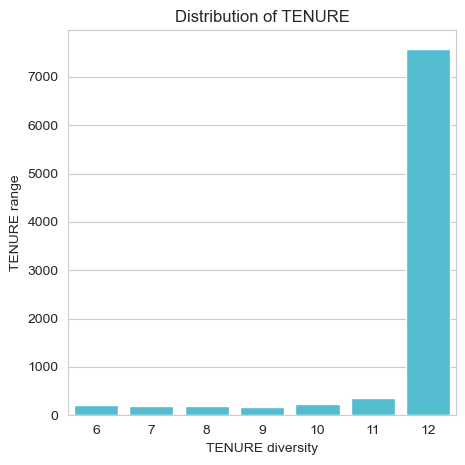

In [ ]:
cor = '#3ecae3'
stack_cor = ['#e2fbff', '#b6f4ff', '#6ae8ff', '#3ecae3', '#1ab5d1', '#0097b2', '#007b91']
discrete_cols = ['TENURE']
fig, ax = plt.subplots(figsize = (5,5))
for col in discrete_cols:
    sns.set_style("whitegrid")
    sns.countplot(data = data_droped, x = data_droped[col].dropna(), color = cor)
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col} diversity')
    plt.ylabel(f'{col} range')
    plt.show()

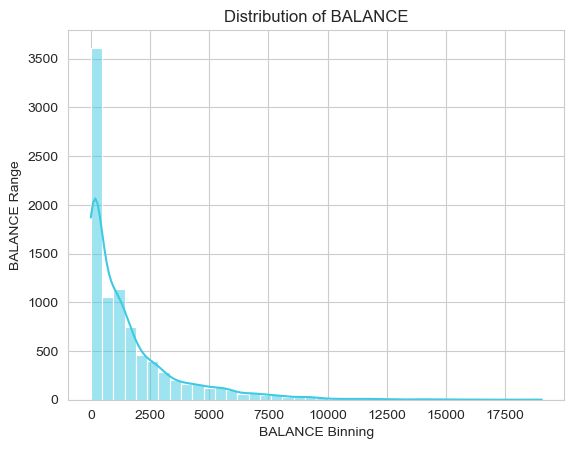

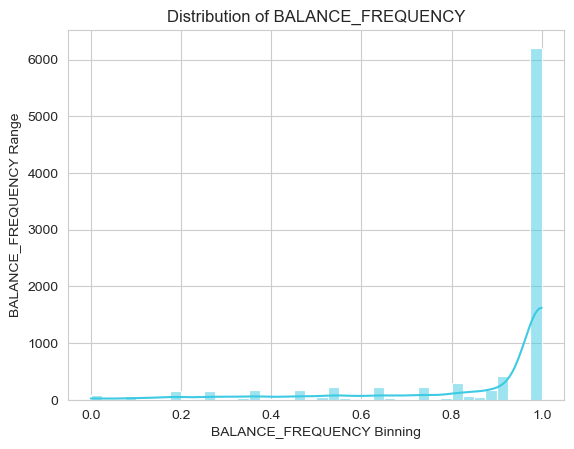

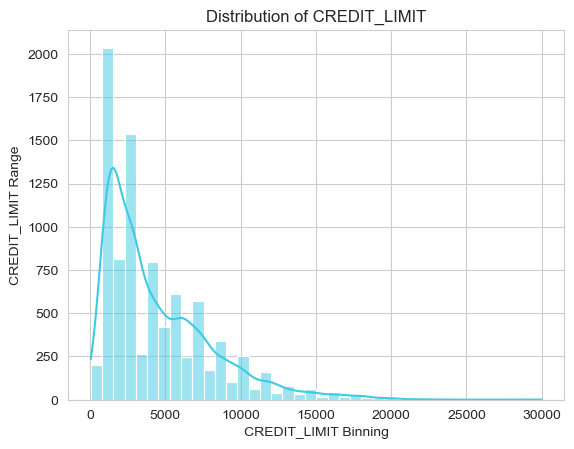

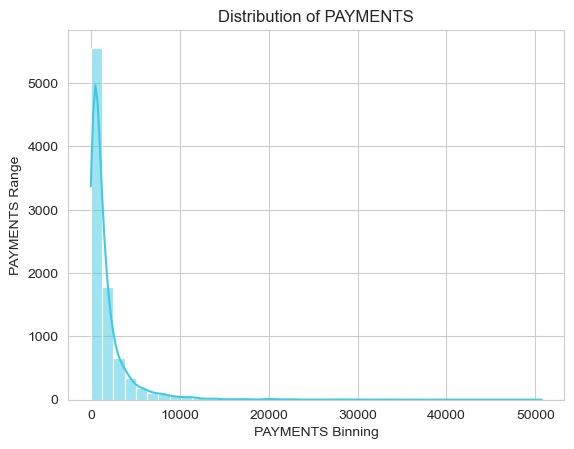

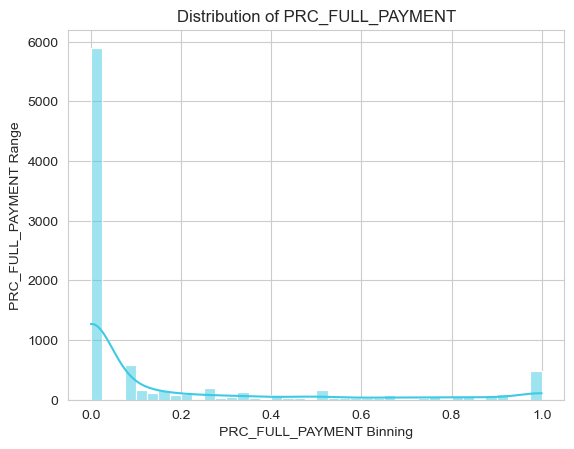

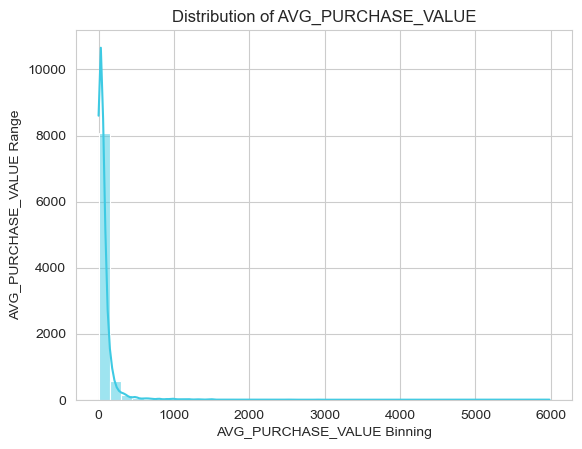

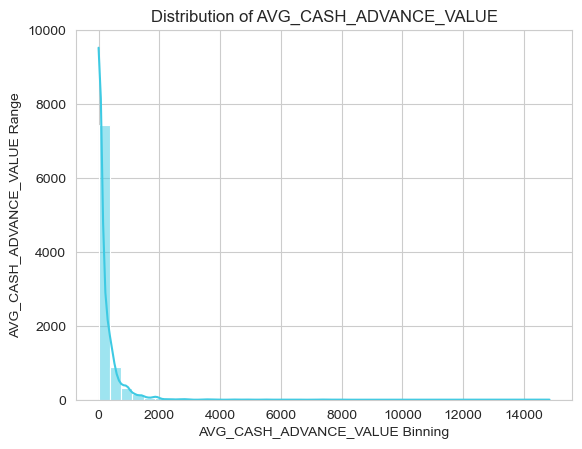

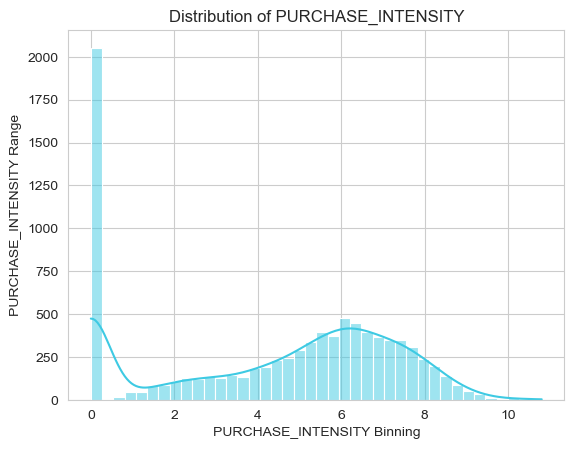

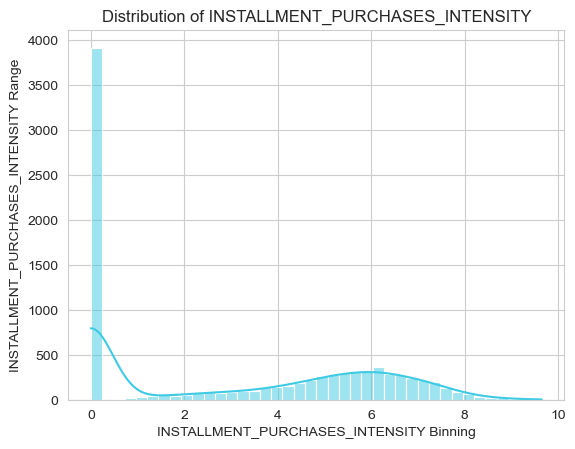

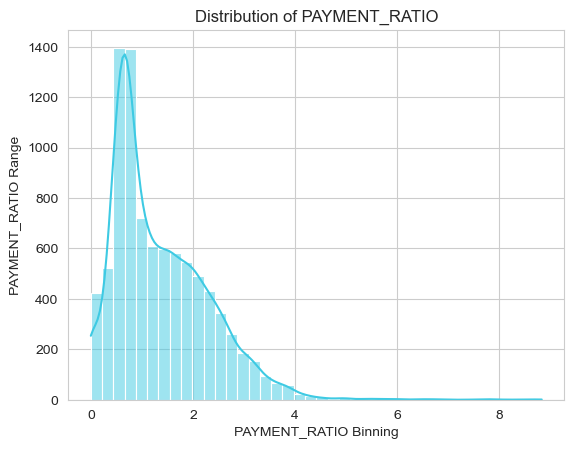

In [ ]:
cont_cols = ['BALANCE', 'BALANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT', 'AVG_PURCHASE_VALUE', 'AVG_CASH_ADVANCE_VALUE', 'PURCHASE_ENGAGEMENT',
             'INSTALLMENT_PURCHASES_ENGAGEMENT', 'PAYMENT_RATIO']

for col in cont_cols:
    sns.set_style("whitegrid")
    sns.histplot(data = data_droped, x = data_droped[col].dropna(), bins = 40, color = cor, kde = True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col} Binning')
    plt.ylabel(f'{col} Range')
    plt.show()

<b><font size="5">Data Preparation for Cluster Analysis</font></b><br><br>

In [ ]:
skewed_cols = ['BALANCE', 'BALANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT', 'AVG_PURCHASE_VALUE', 'AVG_CASH_ADVANCE_VALUE']

for col in skewed_cols:
    data_droped[col] = np.log1p(data_droped[col])
    # shouldnt log1p vars that are already log1p
    # ask chat if i should log1p the others vars bc they are already so compressed

<b><font size="4">Using PCA</font></b><br><br>

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
# RobustScaler is less sensitive to extremes
data_scaled = RobustScaler().fit_transform(data_droped)

# Our data has some correlated variables, different scales and skewed distributions - so we use PCA
pca = PCA(n_components=0.9)  # keep 90% variance
pca_data = pca.fit_transform(data_scaled)

In [16]:
pca_data = pd.DataFrame(pca_data)
pca_data.head()

,0,1,2,3,4,5,6
0,-2.561571,0.074127,-0.916796,-0.283769,1.215188,0.484570,0.682962
1,-0.198775,1.783230,3.882354,1.451852,-1.429067,-0.780440,1.656493
2,-0.169959,-0.335089,-0.493325,-1.877677,1.500173,-0.644760,0.622230
3,-0.613272,-1.043476,-0.715052,1.389883,2.750981,0.174359,0.341906
4,-2.170901,0.301826,-0.428213,-1.604321,1.017007,-0.216016,0.853143


<b><font size="5">Modelling</font></b><br><br>

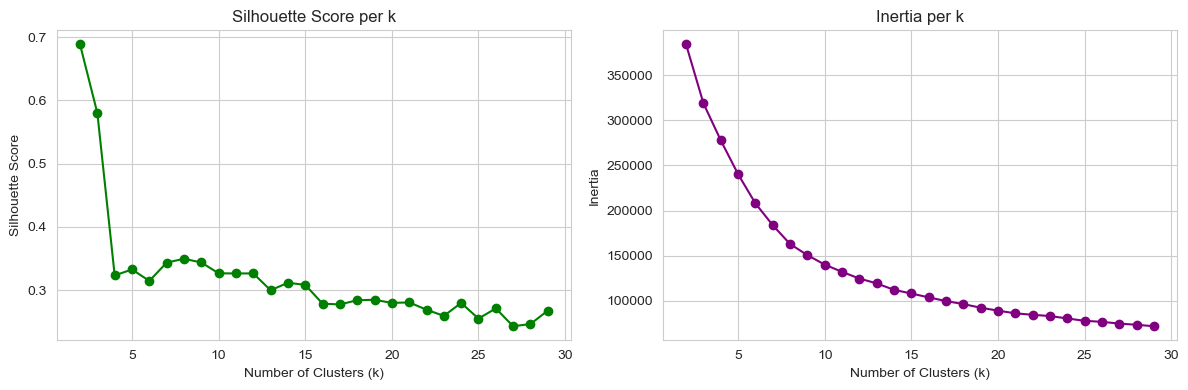

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def find_optimal_k(df, k_range = range(2, 30)):
    silhouette_scores = [] 
    inertia = []
    for k in k_range:
        model = KMeans(n_clusters = k, random_state = 42)
        model.fit(df)
        sil_score = silhouette_score(df, model.labels_)
        silhouette_scores.append(sil_score)
        inertia.append(model.inertia_)
        # print(f"k={k}, silhouette={sil_score:.4f}, inertia={model.inertia_:.0f}")
    return list(k_range), silhouette_scores, inertia

k_range, silhouette_scores, inertia_scores = find_optimal_k(pca_data)

def plot_kmeans_scores(k_range, silhouette_scores, inertia_scores):
    plt.figure(figsize=(12, 4))
    # Silhouette - Local maximums
    plt.subplot(1, 2, 1)
    plt.plot(k_range, silhouette_scores, marker='o', color='green')
    plt.title("Silhouette Score per k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    # Inertia - Elbow method
    plt.subplot(1, 2, 2)
    plt.plot(k_range, inertia_scores, marker='o', color='purple')
    plt.title("Inertia per k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.tight_layout()
    plt.show()

plot_kmeans_scores(k_range, silhouette_scores, inertia_scores)

In [ ]:
# There are plenty local maximums in the silhouette scores (k = [2, 3, 5, 8, 12, 15,...]), but in
# the Inertia plot, the values stabilize at k = 8, so this will be our final choice.